In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data_content = """Sky,AirTemp,Humidity,Wind,Water,Forecast,EnjoySport
Sunny,Warm,Normal,Strong,Warm,Same,Yes
Sunny,Warm,High,Strong,Warm,Same,Yes
Rainy,Cold,High,Strong,Warm,Change,No
Sunny,Warm,High,Strong,Cool,Change,Yes
"""

In [4]:
with open("training_data.csv","w") as f:
    f.write(data_content)

In [5]:
df = pd.read_csv("training_data.csv")
print("---Dataset Loaded---")
print(df)

---Dataset Loaded---
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes


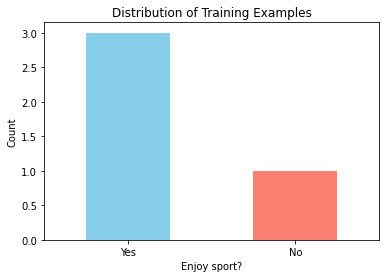

In [7]:
plt.figure(figsize=(6,4))
df['EnjoySport'].value_counts().plot(kind='bar',color=['skyblue','salmon'])
plt.title("Distribution of Training Examples")
plt.xlabel("Enjoy sport?")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [13]:
def candidate_elimination(X,y):
    n_features = X.shape[1]
    first_pos_idx = next(i for i, val in enumerate(y) if val.lower() == 'yes')
    S = list(X[first_pos_idx])
    G = [['?' for _ in range(n_features)]]
    print(f"\nInitial S: {S}")
    print(f"Initial G: {G}\n")
    for i, instance in enumerate(X):
        if y[i].lower() == 'yes':
            for j in range(n_features):
                if instance[j] != S[j]:
                    S[j] = '?'
            G = [g for g in G if all(g[j]=='?' or g[j]== instance[j] for j in range(n_features))]
        else:
            new_G=[]
            for g in G:
                for j in range(n_features):
                    if g[j]=='?' and instance[j] != S[j]:
                        new_hypo = g.copy()
                        new_hypo[j] = S[j]
                        if all(new_hypo[k] == '?' or new_hypo[k] == S[k] for k in range(n_features)):
                            new_G.append(new_hypo)
            G= new_G
        print(f"After Instance {i+1} ({y[i]}):")
        print(f"S: {S}")
        print(f"G: {G}\n")
    return S,G
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

final_S, final_G = candidate_elimination(X,y)


Initial S: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
Initial G: [['?', '?', '?', '?', '?', '?']]

After Instance 1 (Yes):
S: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
G: [['?', '?', '?', '?', '?', '?']]

After Instance 2 (Yes):
S: ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
G: [['?', '?', '?', '?', '?', '?']]

After Instance 3 (No):
S: ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
G: [['Sunny', '?', '?', '?', '?', '?'], ['?', 'Warm', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', 'Same']]

After Instance 4 (Yes):
S: ['Sunny', 'Warm', '?', 'Strong', '?', '?']
G: [['Sunny', '?', '?', '?', '?', '?'], ['?', 'Warm', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?']]



In [14]:
print("-"*30)
print("FINAL VERSION SPACE BOUNDARIES")
print("-"*30)
print(f"Specific Boundary (S): {final_S}")
print(f"General Boundary(G): {final_G}")

------------------------------
FINAL VERSION SPACE BOUNDARIES
------------------------------
Specific Boundary (S): ['Sunny', 'Warm', '?', 'Strong', '?', '?']
General Boundary(G): [['Sunny', '?', '?', '?', '?', '?'], ['?', 'Warm', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?']]
